# wS1/wM1 manuscript figures — MSessionExplorer-format Python pipeline

Reproduces the paper figures from the **original MATLAB-computed results** (behavior / ROC / LDA / ephys tables), flattened to scipy-readable `-v7` structs by `../matlab_export/export_all.m`. Run that in MATLAB once, then run this notebook.

Figures: **Fig1/S1** behavior, **Fig2/S2** opto inhibition, **Fig3** wS1 ephys, **Fig4** S1 ROC, **Fig5** wS1 LDA, **Fig6** wM1 ephys, **Fig7** wM1 LDA.

Each figure cell writes the individual panel PNGs to `FIGROOT/FigN/` **and** displays them as one combined panel (a labeled grid saved as `_panel.png`) so a whole figure can be shown and explained at a glance. Use `show(FIGROOT/'FigN')` instead of `panel(...)` if you'd rather see the panels one below another.

## 1 — Configuration and function setup

In [3]:
import sys
from pathlib import Path

# --- edit these two for your machine ---
# EXPORTS = the -v7 struct exports produced by MATLAB export_all.m
EXPORTS = Path(r"E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\SeData\EphysPassiveStimSEs\SingleUnitAnalysis\PyExports")
# FIGROOT = where to write the figures
FIGROOT = Path(r"E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures")

# make the figure modules importable (this notebook's own folder)
sys.path.insert(0, str(Path.cwd()))
FIGROOT.mkdir(parents=True, exist_ok=True)
print("EXPORTS:", EXPORTS, "| exists:", EXPORTS.exists())
print("FIGROOT:", FIGROOT)

# --- display helpers ---
import glob, math, re
from IPython.display import Image, display, Markdown
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def _figpngs(folder):
    """PNGs a figure step wrote, excluding any montage we made (`_panel.png`)."""
    return sorted(p for p in glob.glob(str(Path(folder) / '*.png'))
                  if 'panel' not in Path(p).stem.lower())

def _short_title(stem):
    """Turn a long output filename into a short, readable tile title
    (files keep their MATLAB-matching names; only the montage label is shortened)."""
    s = str(stem)
    m = re.match(r'(AUC|LDA)_histogram_[^_]+_(WT|KO)_', s)
    if m:
        return f'{m.group(1)} histogram {m.group(2)}'
    m = re.match(r'LDA_bootstrapping_[^_]+_(WT|KO)_', s)
    if m:
        return f'LDA decoding bootstrap ({m.group(1)})'
    if s.startswith('PercentageSigUnit'):
        return 'Percent significant units (bootstrap)' if 'bootstrap' in s.lower() else 'Percent significant units'
    if s.startswith('SigOnset'):
        return 'Selectivity onset'
    return s   # already-short names (e.g. "Fig3C - Normalized FR heatmap WT") pass through

def show(folder, width=560):
    """Show each individual PNG in `folder`, one under another (serial view)."""
    pngs = _figpngs(folder)
    if not pngs:
        display(Markdown(f'*(no figures in {folder})*')); return
    for p in pngs:
        display(Markdown(f'**{_short_title(Path(p).stem)}**'))
        display(Image(filename=p, width=width))

def panel(folder, ncols=None, title=None, width=1000, label_size=11, out_name='_panel.png'):
    """Tile all of a figure's PNGs into ONE labeled grid, save `_panel.png`,
    and display it inline — the presentation view for explaining a figure.
    `label_size` (pt) sets each tile's title; kept >= the plots' own axis-label size."""
    folder = Path(folder)
    pngs = _figpngs(folder)
    if not pngs:
        display(Markdown(f'*(no figures in {folder})*')); return None
    n = len(pngs)
    ncols = ncols or (1 if n == 1 else (2 if n <= 4 else 3))
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.3))
    axes = [axes] if n == 1 else list(axes.ravel())
    for ax, p in zip(axes, pngs):
        ax.imshow(mpimg.imread(p)); ax.axis('off')
        ax.set_title(_short_title(Path(p).stem), fontsize=label_size)
    for ax in axes[n:]:
        ax.axis('off')
    if title:
        fig.suptitle(title, fontsize=label_size + 4)
    fig.tight_layout()
    out = folder / out_name
    fig.savefig(out, dpi=140, bbox_inches='tight'); plt.close(fig)
    display(Image(filename=str(out), width=width))
    return str(out)


EXPORTS: E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\SeData\EphysPassiveStimSEs\SingleUnitAnalysis\PyExports | exists: True
FIGROOT: E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures


## 2 — Fig1: Robo3cKO mice perform a whisker side discrimination task.

Fig1 behavior -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig1
Fig1 panel -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig1\Fig1 - behaviour panels.png


**Fig1 / S1 — behaviour panels**

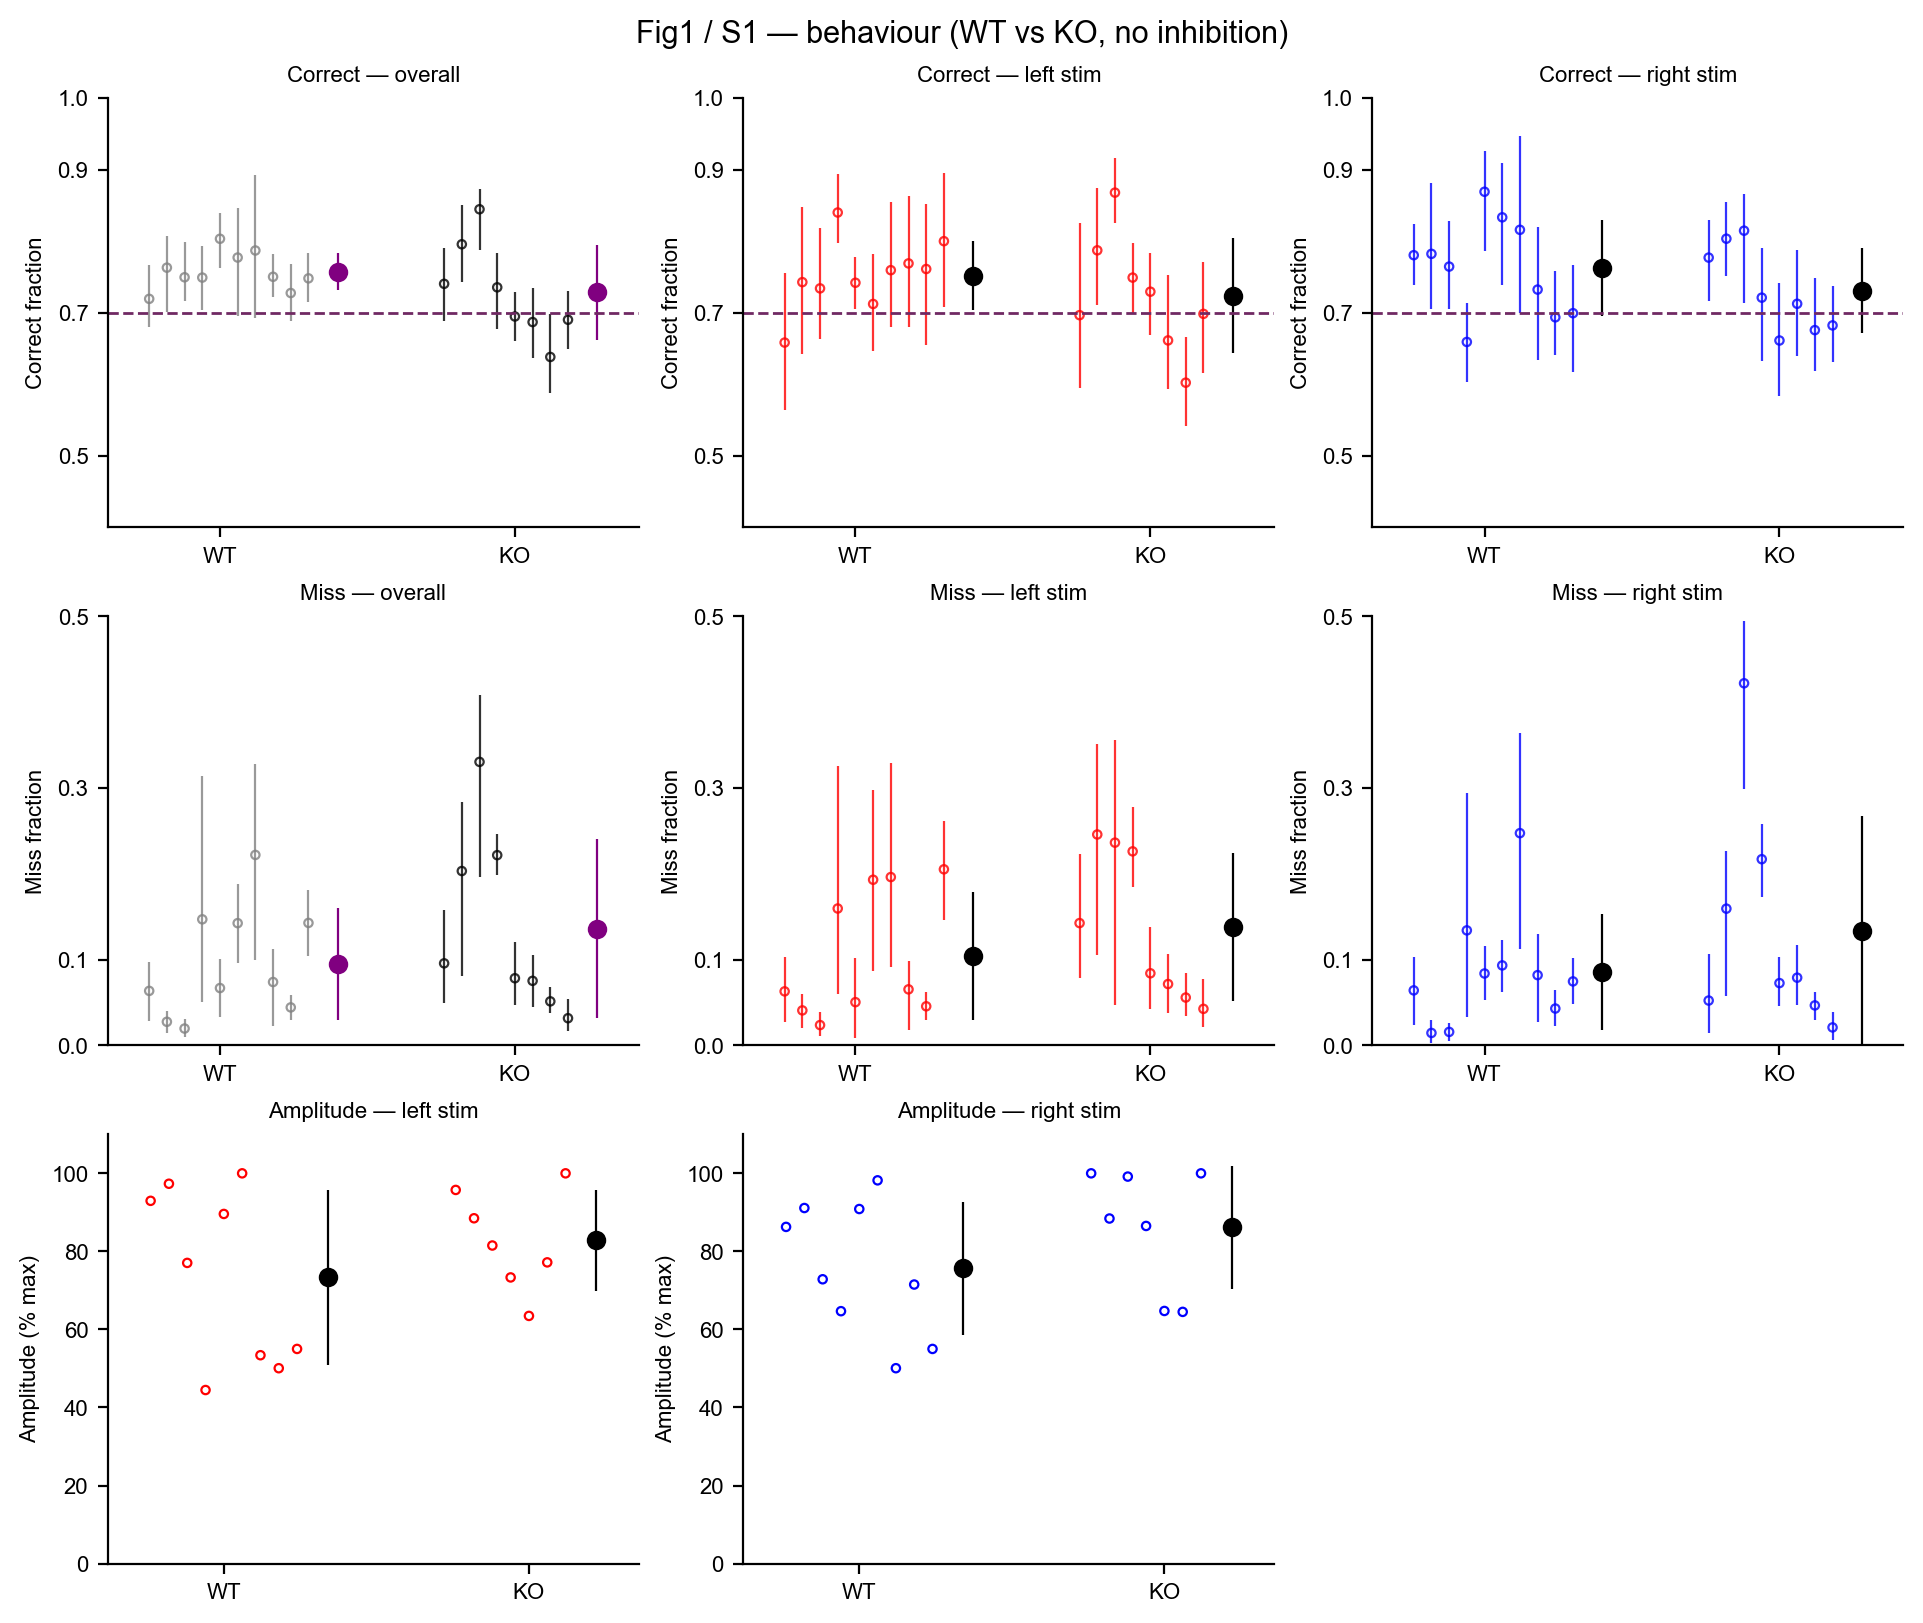

In [4]:
# Fig1/S1 behaviour — combined panel for presenting (also writes the individual panels + stats txt)
import importlib, fig1_behav; importlib.reload(fig1_behav)
fig1_behav.make_fig1(EXPORTS / 'behavior' / 'Fig1', FIGROOT / 'Fig1')          # 8 individual panels + Fig1behavMeanvals.txt
fig1_behav.make_fig1_panel(EXPORTS / 'behavior' / 'Fig1', FIGROOT / 'Fig1')     # single 3x3 panel figure
display(Markdown('**Fig1 / S1 — behaviour panels**'))
display(Image(filename=str(FIGROOT / 'Fig1' / 'Fig1 - behaviour panels.png'), width=920))


## 3 — Fig2: Contralateral wS1 activity is critical for reporting the side of a whisker stimulus.

Fig2 opto inhibition -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig2


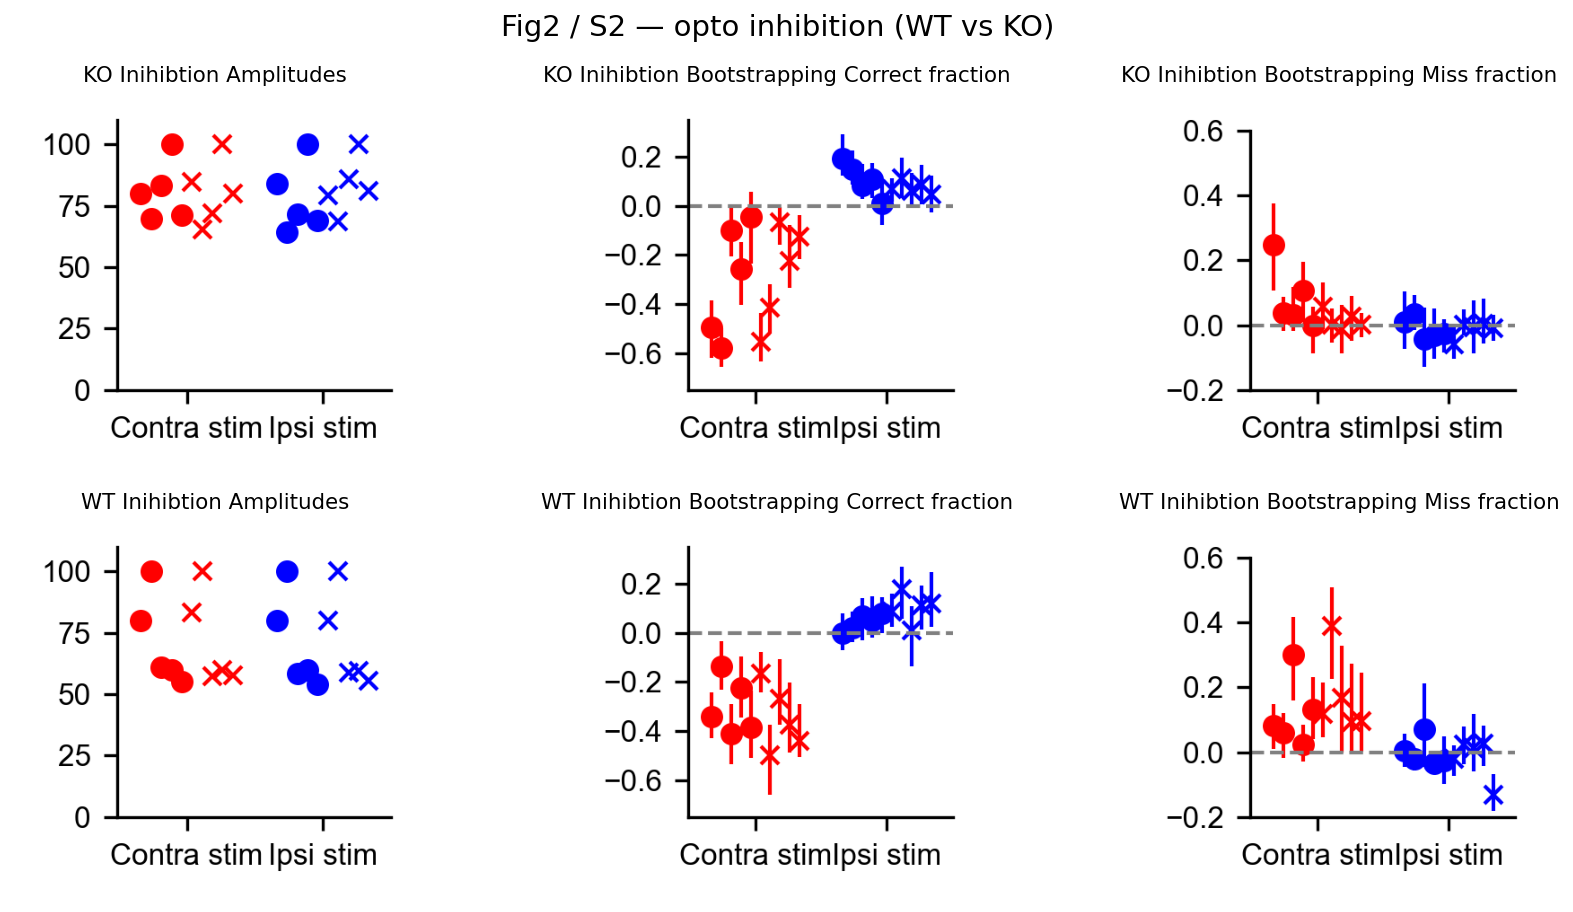

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig2\\_panel.png'

In [5]:
# Fig2/S2 opto inhibition — needs export_fig2.m first (flattens InhibitionAllVars)
import importlib, fig2_optoinhib; importlib.reload(fig2_optoinhib)
fig2_optoinhib.make_fig2(EXPORTS / 'behavior' / 'Fig2', FIGROOT / 'Fig2')
panel(FIGROOT / 'Fig2', title='Fig2 / S2 — opto inhibition (WT vs KO)')


## 4 — Fig3: Ipsilateral and contralateral whisker responses in wS1. 

S1: 1044 units (243 responsive)
ephys panels (S1) -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig3


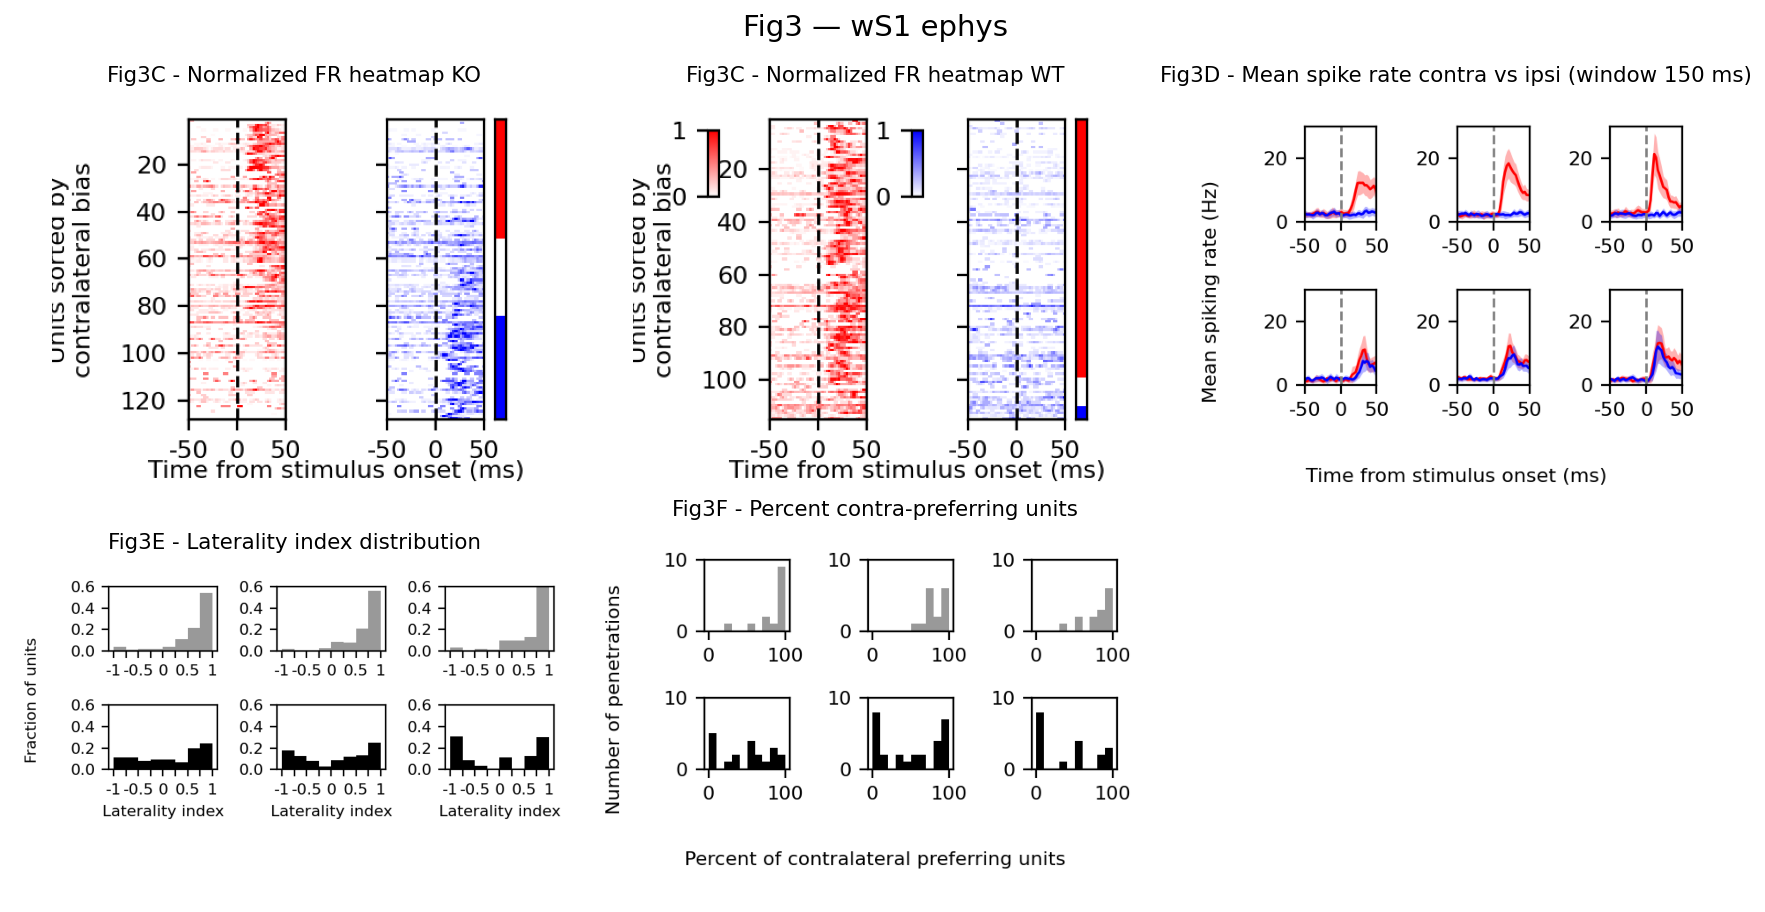

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig3\\_panel.png'

In [6]:
# needs export_fig3.m (region 'S1') run first -> PyExports/ephys/fig3_tables_S1.mat
# reload the whole ephys chain (fig3_ephys -> fig3_panels_nwb -> fig3_analysis_nwb),
# deepest first, so edits to the plotters actually take effect without a kernel restart
import importlib, fig3_analysis_nwb, fig3_panels_nwb, fig3_ephys
importlib.reload(fig3_analysis_nwb); importlib.reload(fig3_panels_nwb); importlib.reload(fig3_ephys)
fig3_ephys.make_ephys_figs(EXPORTS / 'ephys' / 'fig3_tables_S1.mat', FIGROOT / 'Fig3', region='S1')
panel(FIGROOT / 'Fig3', title='Fig3 — wS1 ephys')


## 5 — Fig4: Trial-by-trial discrimination of whisker side by single neurons in wS1. 

Fig4A AUC histograms (S1) written -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig4
Fig4 percent-significant-over-time (S1) -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig4
Fig4 percent-significant bootstrap (S1, seed=0) -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig4
Fig4 selectivity onset (S1) -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig4  [WT con/ipsi sig: 45; KO: 34]


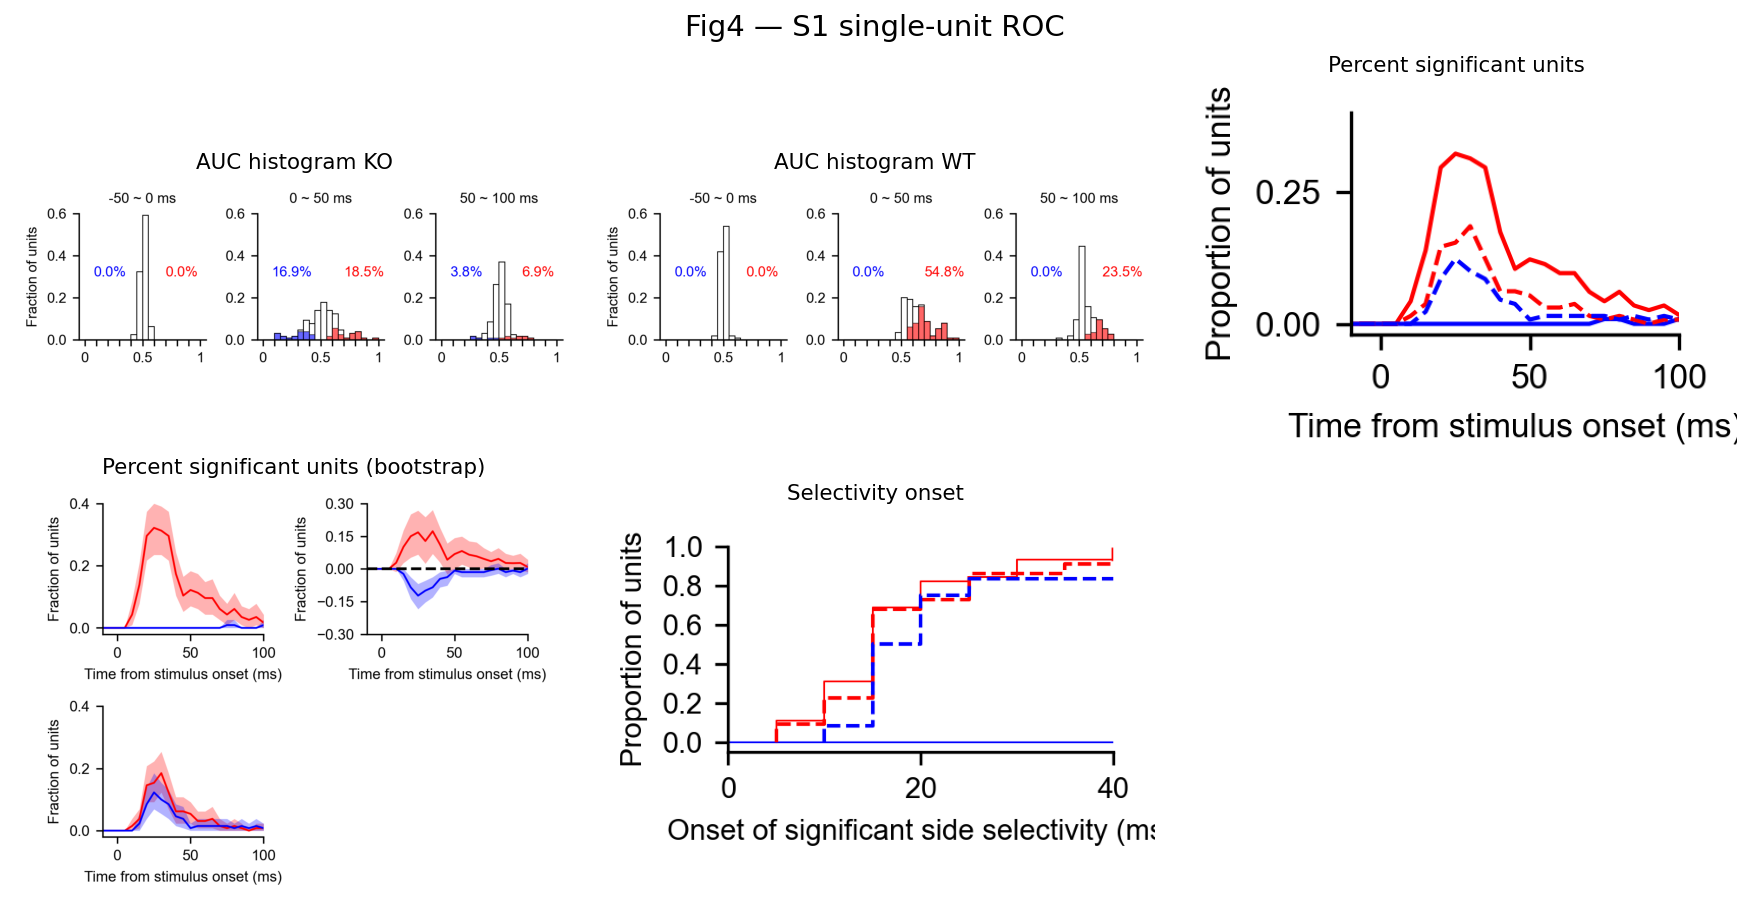

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig4\\_panel.png'

In [7]:
# Fig4 — S1 single-unit ROC (needs export_roc.m first: 50msBin + 5msBin)
import importlib, fig4_roc; importlib.reload(fig4_roc)
roc50 = EXPORTS / 'S1' / 'ROC' / '50msBin'
roc5  = EXPORTS / 'S1' / 'ROC' / '5msBin'
fig4_roc.auc_histograms(roc50, FIGROOT / 'Fig4', site='S1')          # Fig4A
fig4_roc.percent_sig_over_time(roc5, FIGROOT / 'Fig4', site='S1')     # % sig over time
fig4_roc.percent_sig_bootstrap(roc5, FIGROOT / 'Fig4', site='S1')     # + bootstrap CI
fig4_roc.selectivity_onset(roc5, FIGROOT / 'Fig4', site='S1')         # Fig4D onset
panel(FIGROOT / 'Fig4', title='Fig4 — S1 single-unit ROC')


## 6 — Fig5 — Population-level discrimination of whisker side by wS1.

LDA figures (S1) written -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig5


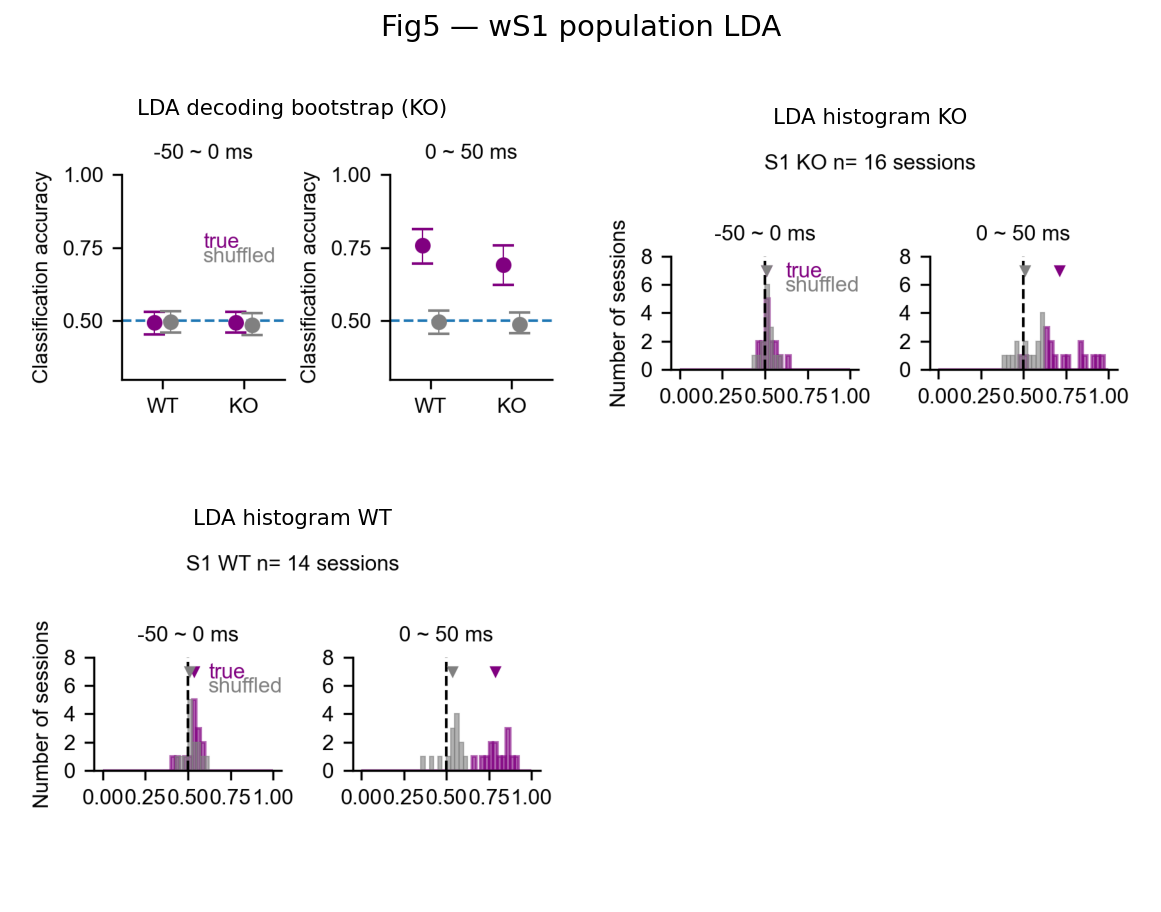

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig5\\_panel.png'

In [8]:
# Fig5 — wS1 population LDA decoding
import importlib, fig5_lda; importlib.reload(fig5_lda)
fig5_lda.make_lda_figures(EXPORTS / "S1" / "LDA" / "50msBin", FIGROOT / "Fig5",
                          site="S1", bin_s=0.05, time_window=(-0.05, 0.05))
panel(FIGROOT / 'Fig5', title='Fig5 — wS1 population LDA')


## 7 — Fig6: Contralaterally selective whisker responses in wM1.

M1: 3364 units (276 responsive)
ephys panels (M1) -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig6


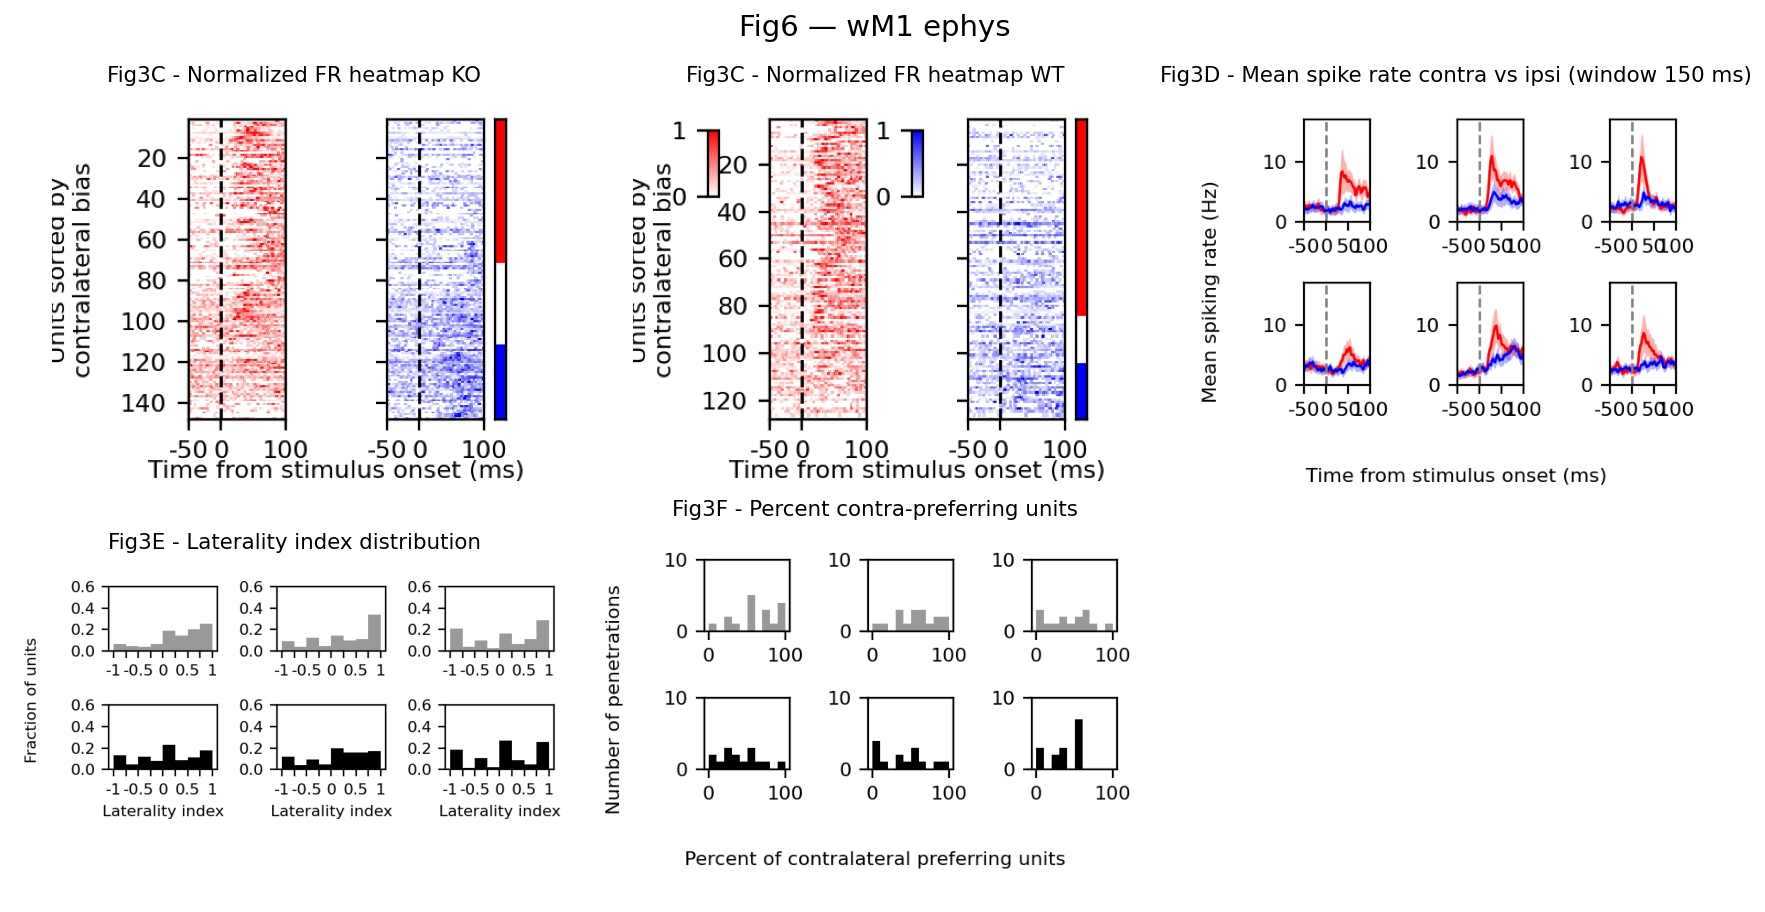

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig6\\_panel.png'

In [9]:
# needs export_fig3.m (region 'M1') run first -> PyExports/ephys/fig3_tables_M1.mat
# reload the whole ephys chain (deepest first) so plotter edits take effect
import importlib, fig3_analysis_nwb, fig3_panels_nwb, fig3_ephys
importlib.reload(fig3_analysis_nwb); importlib.reload(fig3_panels_nwb); importlib.reload(fig3_ephys)
fig3_ephys.make_ephys_figs(EXPORTS / 'ephys' / 'fig3_tables_M1.mat', FIGROOT / 'Fig6', region='M1')
panel(FIGROOT / 'Fig6', title='Fig6 — wM1 ephys')


## 8 — Fig8: Population-level discrimination of whisker side by wM1.

LDA figures (Motor) written -> E:\oconnorlab Dropbox\oconnorlab Team Folder\manuscripts\bodyside_S1\MSE_python_figures\Fig7


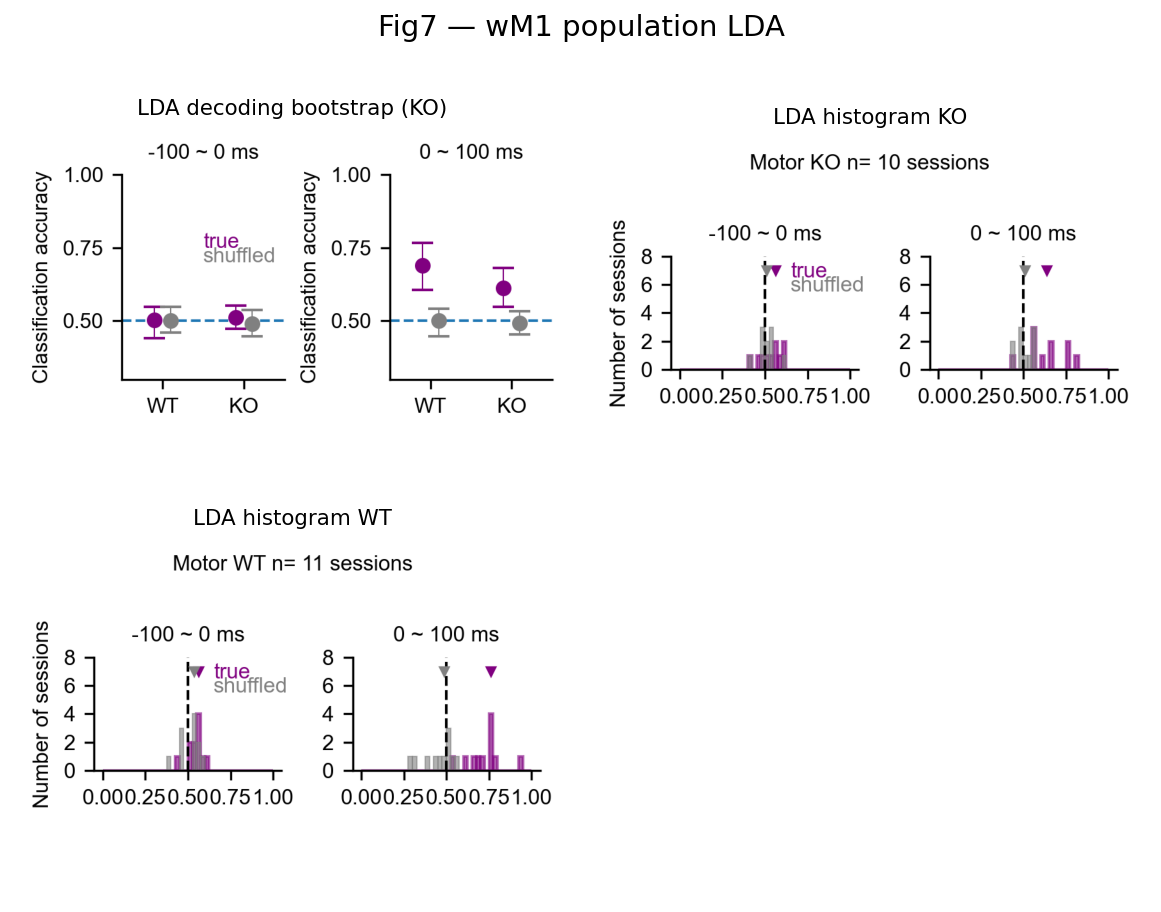

'E:\\oconnorlab Dropbox\\oconnorlab Team Folder\\manuscripts\\bodyside_S1\\MSE_python_figures\\Fig7\\_panel.png'

In [10]:
# Fig7 — wM1 population LDA decoding (same code as Fig5, Motor params)
import importlib, fig7_lda_motor  # imports fig5_lda.make_lda_figures internally
from fig5_lda import make_lda_figures
make_lda_figures(EXPORTS / "Motor" / "LDA" / "100msBin", FIGROOT / "Fig7",
                 site="Motor", bin_s=0.1, time_window=(-0.1, 0.1), legend_x=0.65)
panel(FIGROOT / 'Fig7', title='Fig7 — wM1 population LDA')


## Done